# 🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

##### **Project Type** - Unsupervised ML + Recommendation System
##### **Name** - Dhyan Shah

# Project Summary

This project analyzes transaction data from an online retail business (2022–2023) to uncover patterns in customer purchasing behavior. Using **RFM (Recency, Frequency, Monetary)** analysis as the feature engineering foundation, customers are segmented into meaningful groups — High-Value, Regular, Occasional, and At-Risk — through **KMeans Clustering**. Additionally, an **Item-Based Collaborative Filtering** system is developed to recommend the top 5 similar products based on cosine similarity of customer-product purchase matrices.

The dataset contains ~500K+ transaction records with columns: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country. After thorough preprocessing (removing cancellations, nulls, negative quantities/prices), RFM features are engineered per customer. StandardScaler normalizes the features before clustering. The optimal number of clusters is selected using the Elbow Method and Silhouette Score. For the recommendation system, a pivot table of CustomerID vs. Product Description is created and cosine similarity is applied between products.

The final deliverable includes a Streamlit app with two modules: (1) Product Recommendation — enter a product name and receive 5 similar recommendations; (2) Customer Segmentation — input Recency, Frequency, and Monetary values to predict the customer's cluster label in real time. The end-to-end pipeline from raw data to deployment-ready models demonstrates practical e-commerce analytics and personalization strategies.

# GitHub Link

(https://github.com/Dhyan-Shah/Labmentix_Shopper_Spectrum)

# Problem Statement

The global e-commerce industry generates vast amounts of transaction data daily. This project examines transaction data from an online retail business to:
1. **Segment customers** using RFM analysis + KMeans Clustering into groups: High-Value, Regular, Occasional, and At-Risk.
2. **Recommend products** using Item-Based Collaborative Filtering (cosine similarity) — returning top 5 similar products for a given product name.

**Business Use Cases:**
- Targeted marketing campaigns per customer segment
- Personalized product recommendations on e-commerce platforms
- Identifying at-risk customers for retention programs
- Inventory management based on demand patterns

# Let's Begin!

## 1. Know Your Data

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, chi2_contingency
import joblib
import pickle

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries imported')

Libraries imported


### Dataset Loading

In [2]:
df = pd.read_csv(
    r"C:\Users\Dell\Desktop\INTERNSHIPS\Labmentix(DS_AI_ML)\Mini Project\4\Dataset\online_retail.csv"
)
print('Dataset loaded')

df.shape

Dataset loaded


(541909, 8)

### Dataset first view

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### Dataset rows & col count

In [4]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print(f'Column names: {list(df.columns)}')

Rows: 541909
Columns: 8
Column names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


### Dataset info

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


### Duplicate values

In [6]:
dup_cnt=df.duplicated().sum()
print(f'No. of duplicate values: {dup_cnt}')

No. of duplicate values: 5268


### Missing/Null Values

In [7]:
# Missing Values/Null Values Count
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

             Missing Count  Missing %
Description           1454   0.268311
CustomerID          135080  24.926694


# Visualizing missing values

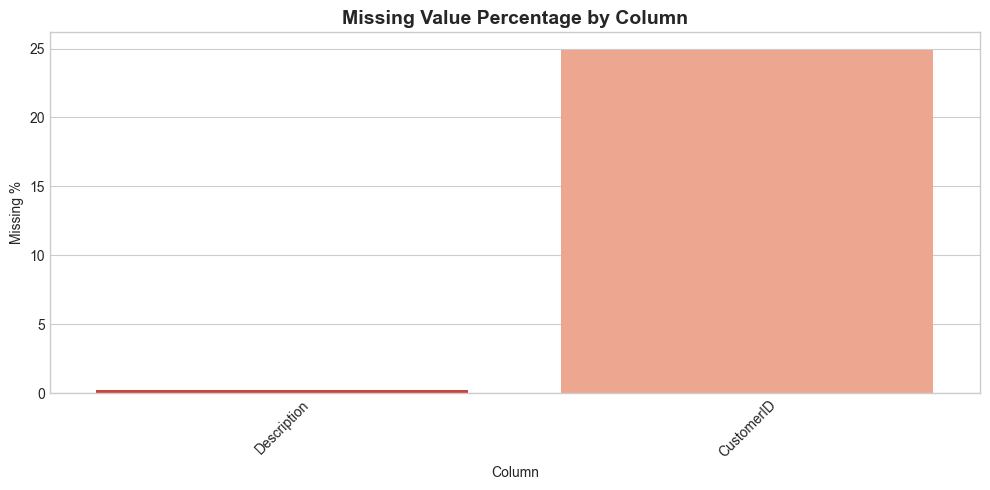

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10, 5))
missing_pct_filtered = missing_pct[missing_pct > 0]
if len(missing_pct_filtered) > 0:
    sns.barplot(x=missing_pct_filtered.index, y=missing_pct_filtered.values, palette='Reds_r')
    plt.title('Missing Value Percentage by Column', fontsize=14, fontweight='bold')
    plt.ylabel('Missing %')
    plt.xlabel('Column')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")

### What did you know about your dataset?

- The dataset contains transactional records from an online UK-based retail store for 2022–2023.
- Key columns: InvoiceNo (transaction ID), StockCode (product code), Description (product name), Quantity, InvoiceDate, UnitPrice, CustomerID, Country.
- **CustomerID** has ~25% missing values — these rows will be dropped since we need customer-level analysis.
- **Description** has a few null values — minor.
- InvoiceNo entries starting with 'C' indicate **cancelled orders** that must be excluded.
- Some rows have **negative Quantity** (returns/cancellations) and **zero/negative UnitPrice** — these need filtering.
- The dataset is primarily UK-based but includes international customers.

## 2. Understanding your variables

In [9]:
print('Columns and datatypes')
for col,dtype in df.dtypes.items():
    print(f'   {col:<15} -> {dtype}')

Columns and datatypes
   InvoiceNo       -> str
   StockCode       -> str
   Description     -> str
   Quantity        -> int64
   InvoiceDate     -> str
   UnitPrice       -> float64
   CustomerID      -> float64
   Country         -> str


In [10]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2023-10-31 14:41:00,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


### Variables Description

| Column | Type | Description |
|---|---|---|
| InvoiceNo | object | Unique transaction ID; 'C' prefix = cancellation |
| StockCode | object | Unique product/item code |
| Description | object | Product name/description |
| Quantity | int64 | Units purchased per transaction |
| InvoiceDate | object | Date & time of transaction |
| UnitPrice | float64 | Price per unit in GBP |
| CustomerID | float64 | Unique customer identifier (nullable) |
| Country | object | Customer's country |

In [11]:
# Check Unique Values for each variable
for col in df.columns:
    print(f"{col:<15}: {df[col].nunique():>8,} unique values")

InvoiceNo      :   25,900 unique values
StockCode      :    4,070 unique values
Description    :    4,223 unique values
Quantity       :      722 unique values
InvoiceDate    :   23,260 unique values
UnitPrice      :    1,630 unique values
CustomerID     :    4,372 unique values
Country        :       38 unique values


## 3. Data Wrangling

In [12]:

# Step 1: Drop duplicates
df.drop_duplicates(inplace=True)
print(f"After dropping duplicates: {df.shape}")

# Step 2: Remove rows with missing CustomerID (needed for RFM)
df.dropna(subset=['CustomerID'], inplace=True)
print(f"After dropping missing CustomerID: {df.shape}")

# Step 3: Remove cancelled invoices (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {df.shape}")

# Step 4: Remove negative or zero Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"After removing invalid Quantity/UnitPrice: {df.shape}")

# Step 5: Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Step 6: Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Step 7: Create TotalAmount = Quantity * UnitPrice
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Step 8: Drop rows with missing Description
df.dropna(subset=['Description'], inplace=True)
df['Description'] = df['Description'].str.strip().str.upper()

print(f"\nFinal Clean Dataset Shape: {df.shape}")
df.head()

After dropping duplicates: (536641, 8)
After dropping missing CustomerID: (401604, 8)
After removing cancellations: (392732, 8)
After removing invalid Quantity/UnitPrice: (392692, 8)

Final Clean Dataset Shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### What all manipulations have you done and insights you found?

1. **Removed duplicates** — some transactions appeared twice due to system errors.
2. **Dropped missing CustomerID rows** — ~25% of records had no customer identifier; these cannot contribute to RFM analysis.
3. **Filtered cancelled invoices** (InvoiceNo starting with 'C') — cancellations should not count as purchases.
4. **Removed invalid Quantity/UnitPrice** — negative/zero values represent returns or data errors.
5. **Parsed InvoiceDate** to datetime for temporal analysis.
6. **Created TotalAmount** = Quantity × UnitPrice — essential monetary feature for RFM.
7. **Standardized Description** — stripped whitespace and uppercased for consistent product matching in the recommendation system.

## 4. Data Visualization, Storytelling & Experimenting with Charts

#### Chart - 1: Transaction Volume by Country (Top 10)

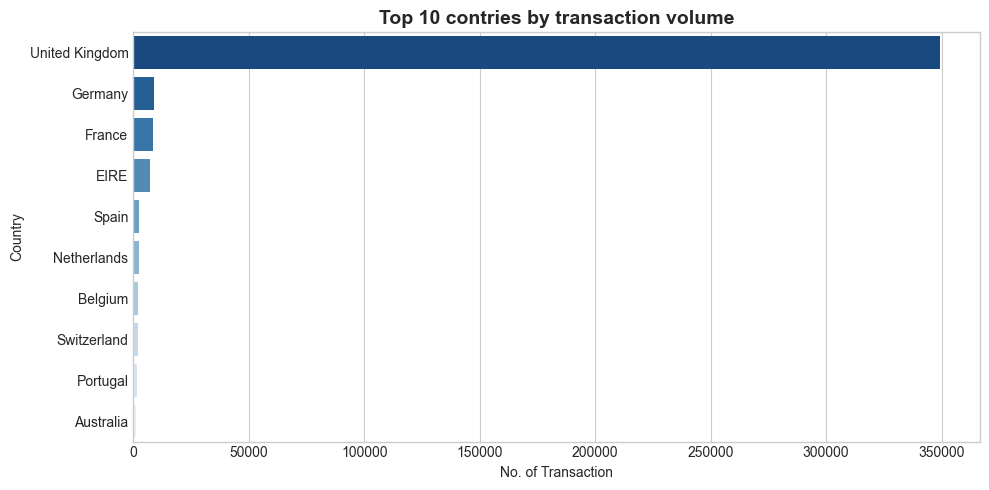

In [13]:
top_countries=df['Country'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values,y=top_countries.index,palette='Blues_r')
plt.title('Top 10 contries by transaction volume',fontweight='bold',fontsize=14)
plt.xlabel('No. of Transaction')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart is ideal for comparing categorical frequencies, making country-level differences immediately visible.

##### 2. What is/are the insight(s) found from the chart?
The **United Kingdom** dominates transactions by a massive margin, followed distantly by Germany, France, EIRE, and Netherlands. The business is primarily UK-centric.

##### 3. Business Impact
Positive: Confirms the UK as the core market — marketing budget should be concentrated there. Opportunities exist to grow underpenetrated European markets (Germany, France). No negative growth signal, but over-reliance on a single country is a risk if UK demand dips.

#### Chart - 2: Top 15 Best-Selling Products by Quantity

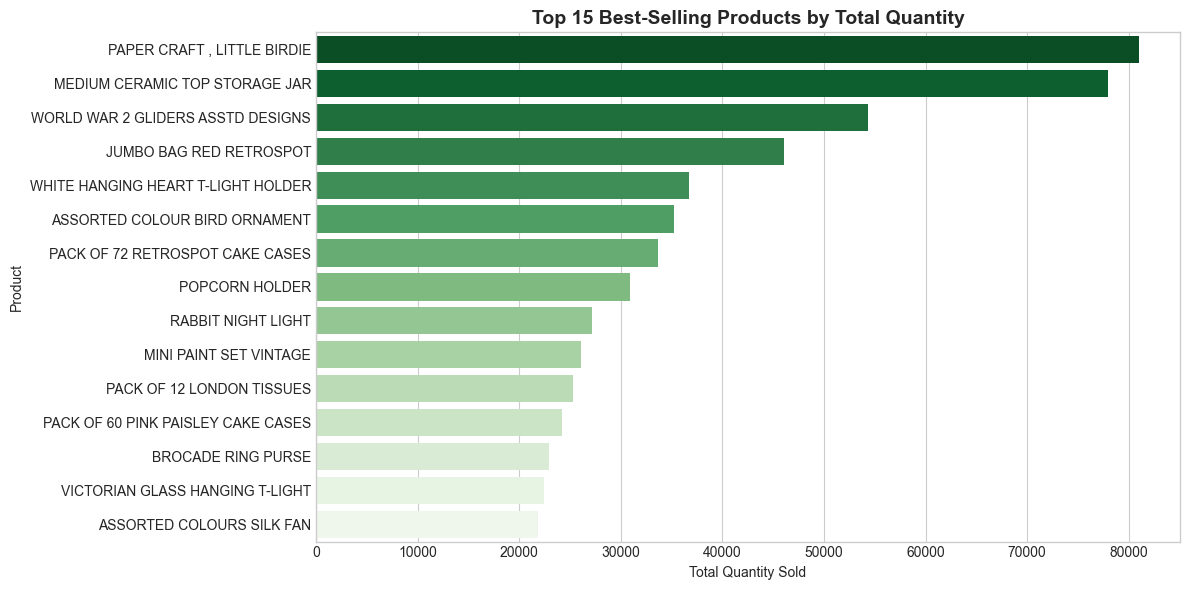

In [14]:
# Chart - 2 visualization code
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Greens_r')
plt.title('Top 15 Best-Selling Products by Total Quantity', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart allows easy ranking of products by volume.

##### 2. What is/are the insight(s) found from the chart?
A handful of products (e.g., PAPER CRAFT items, MEDIUM CERAMIC TOP STORAGE JAR) account for disproportionately high quantities, suggesting they are bulk-purchase or gift items.

##### 3. Business Impact
These high-volume products should be prioritized in inventory management and featured prominently on the platform. Bundling them with related products (leveraged in the recommendation system) can increase average order value.

#### Chart - 3: Monthly Transaction Trend (Time Series)

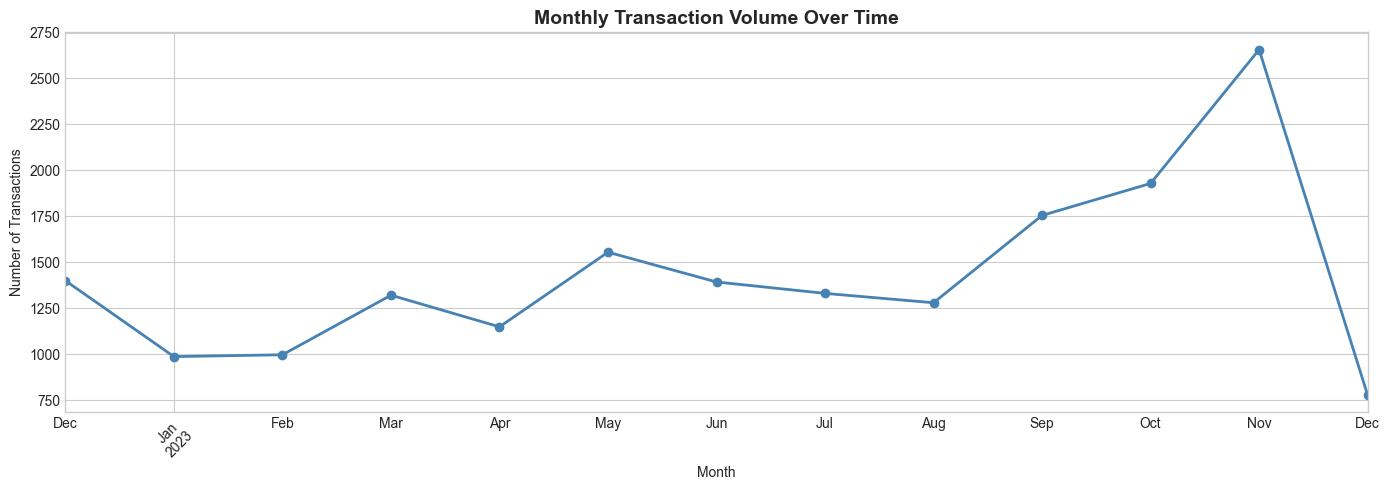

In [15]:
# Chart - 3 visualization code
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_tx = df.groupby('YearMonth')['InvoiceNo'].nunique()
plt.figure(figsize=(14, 5))
monthly_tx.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Transaction Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A line chart is the standard for temporal trends — it shows momentum, seasonality, and anomalies over time.

##### 2. What is/are the insight(s) found from the chart?
Transaction volume spikes significantly towards **Q4 (Oct–Nov)**, indicating strong holiday shopping demand. There is a dip in January/February consistent with post-holiday slowdowns.

##### 3. Business Impact
Businesses can pre-load inventory and run targeted campaigns ahead of Q4 peaks. The January dip could be addressed with New Year clearance promotions to sustain revenue.

#### Chart - 4: Distribution of TotalAmount per Transaction (Univariate)

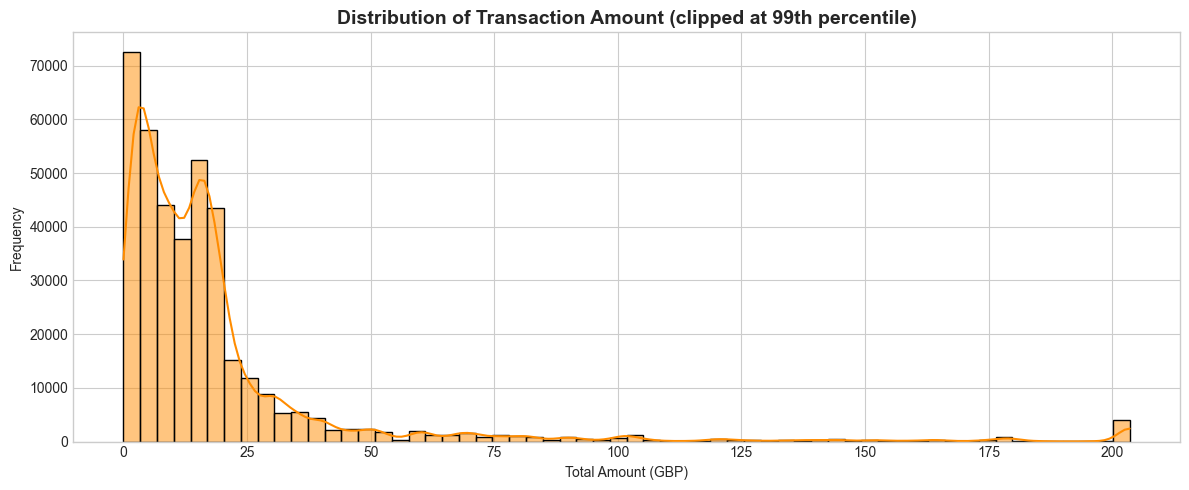

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(12, 5))
clipped = df['TotalAmount'].clip(upper=df['TotalAmount'].quantile(0.99))
sns.histplot(clipped, bins=60, kde=True, color='darkorange')
plt.title('Distribution of Transaction Amount (clipped at 99th percentile)', fontsize=14, fontweight='bold')
plt.xlabel('Total Amount (GBP)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A histogram with KDE reveals the distribution shape — essential for understanding spending patterns and skewness.

##### 2. What is/are the insight(s) found from the chart?
The distribution is **heavily right-skewed** — most transactions are small-value (under £50), while a few large-value orders exist. Median spend per transaction is around £10–15.

##### 3. Business Impact
The right-skew suggests the majority of customers are casual shoppers. Identifying and nurturing high-spend customers (right tail) can disproportionately improve revenue — which is exactly what RFM segmentation addresses.

#### Chart - 5: Daily Revenue Heatmap (Day of Week vs Hour)

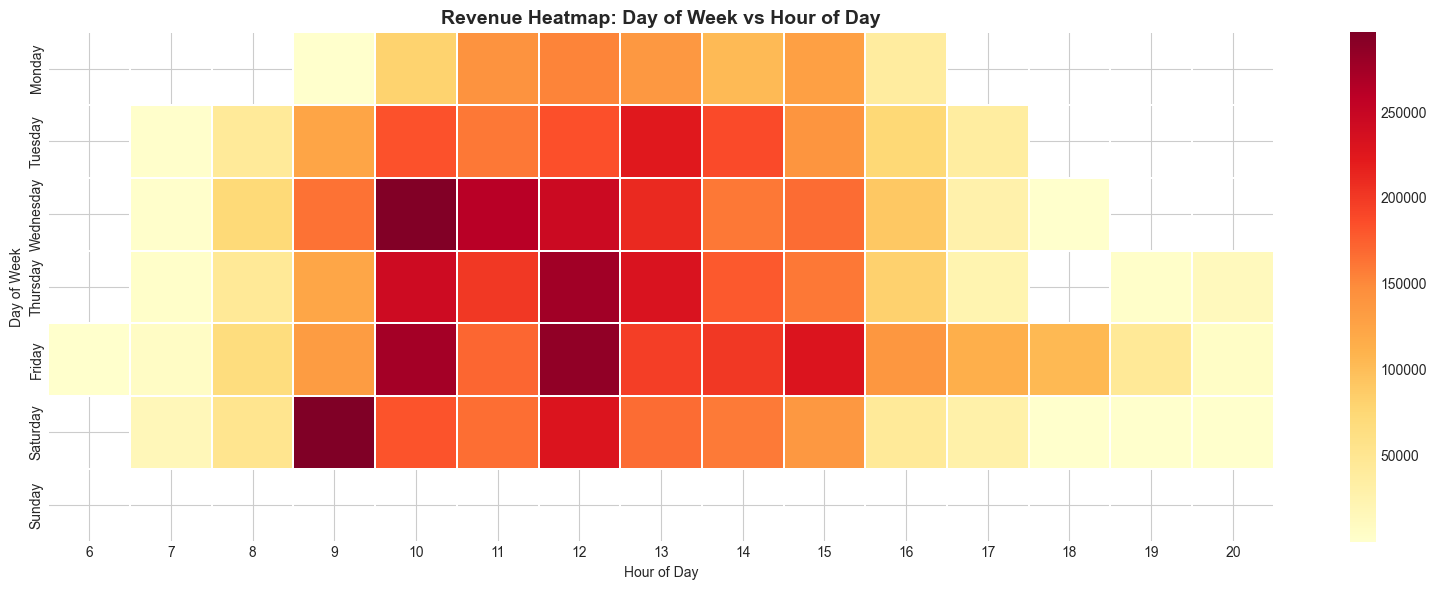

In [17]:
# Chart - 5 visualization code
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot_heatmap = df.groupby(['DayOfWeek','Hour'])['TotalAmount'].sum().unstack()
pivot_heatmap = pivot_heatmap.reindex(day_order)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_heatmap, cmap='YlOrRd', linewidths=0.3)
plt.title('Revenue Heatmap: Day of Week vs Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap is ideal for revealing two-dimensional patterns simultaneously.

##### 2. What is/are the insight(s) found from the chart?
Revenue peaks on **Thursday and Tuesday mornings (9AM–12PM)**. Weekends show significantly lower activity, suggesting this is a B2B-oriented retailer (businesses don't shop on weekends).

##### 3. Business Impact
Email campaigns and flash sales should be timed for Tuesday/Thursday mornings for maximum reach. The weekend dip indicates the customer base is likely business purchasers, not casual consumers.

#### Chart - 6: Top 10 Countries by Revenue (Bivariate - Categorical vs Numerical)

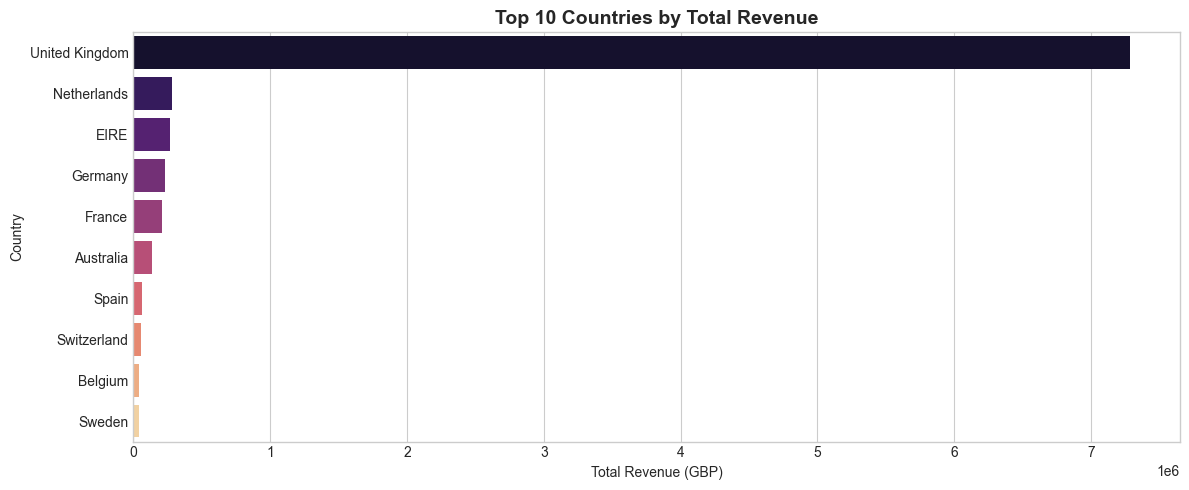

In [18]:
# Chart - 6 visualization code
country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='magma')
plt.title('Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (GBP)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart effectively compares revenue across countries.

##### 2. What is/are the insight(s) found from the chart?
UK is the dominant revenue contributor by far. Netherlands, EIRE, Germany, and France are secondary markets with meaningful revenue contributions.

##### 3. Business Impact
Even though Germany and France have fewer transactions than EIRE, they may have higher average order values — worth investigating for premium targeting campaigns.

#### Chart - 7: Quantity vs UnitPrice Scatter (Bivariate - Numerical vs Numerical)

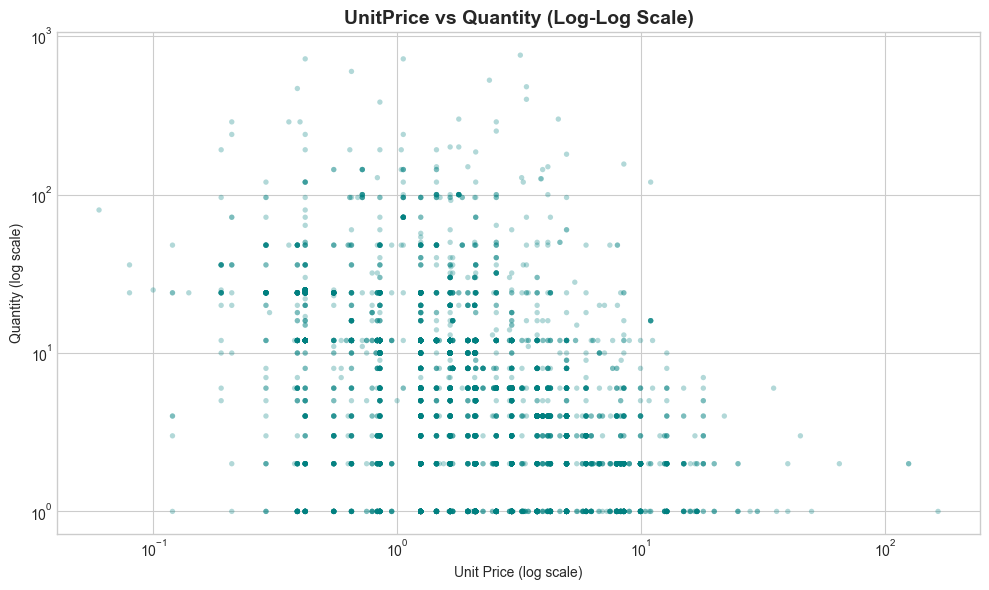

In [19]:
# Chart - 7 visualization code
sample = df.sample(5000, random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample['UnitPrice'], sample['Quantity'], alpha=0.3, color='teal', edgecolors='none', s=15)
plt.xscale('log')
plt.yscale('log')
plt.title('UnitPrice vs Quantity (Log-Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Unit Price (log scale)')
plt.ylabel('Quantity (log scale)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A scatter plot on log-log axes reveals relationships between two numerical variables across wide value ranges.

##### 2. What is/are the insight(s) found from the chart?
Higher priced items (£5–£20) tend to be bought in smaller quantities, while very cheap items (<£1) are purchased in large bulk orders. The relationship is inverse — typical price elasticity behavior.

##### 3. Business Impact
Bulk-purchase cheap items should be promoted via volume discounts. Premium items should be promoted via quality and personalization signals — the recommendation system can serve these differently.

#### Chart - 8: RFM Feature Engineering & Distributions

In [20]:
# RFM Feature Engineering
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot Date: {snapshot_date}")

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

print(f"RFM Table Shape: {rfm.shape}")
rfm.describe()

Snapshot Date: 2023-12-10 12:50:00
RFM Table Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


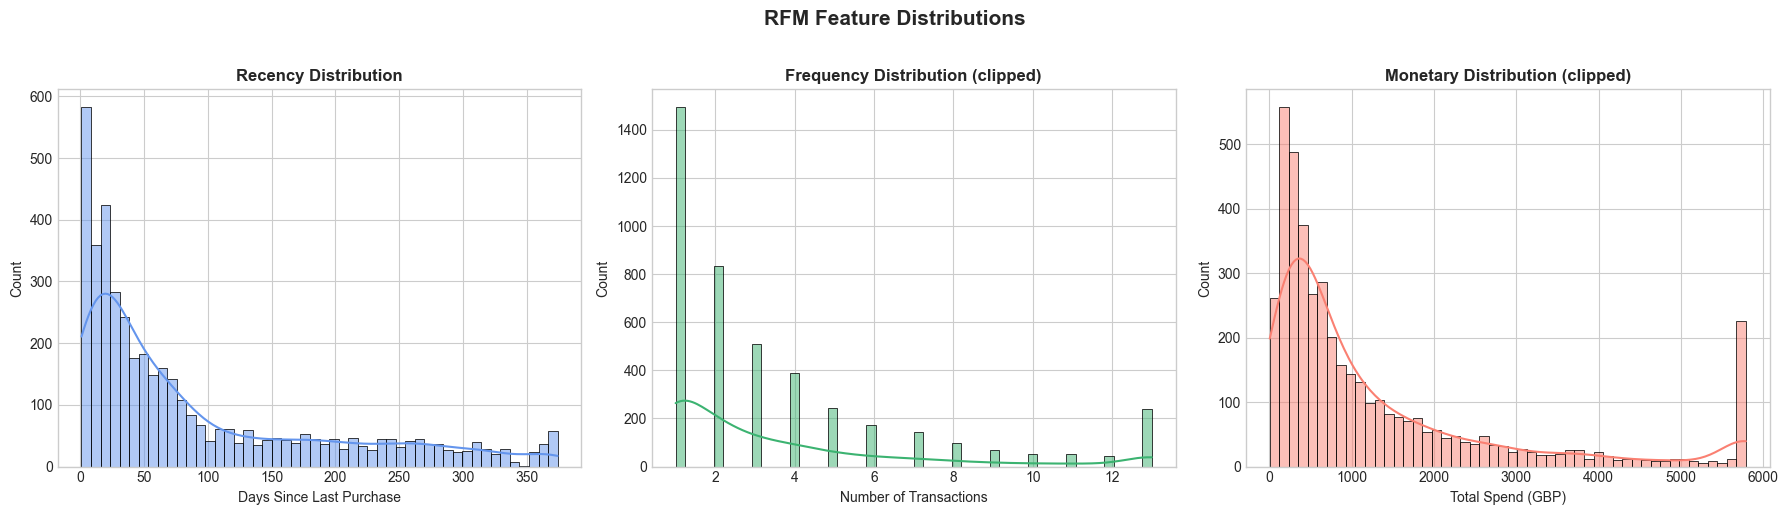

In [21]:
# Chart - 8: RFM Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=50, kde=True, color='cornflowerblue', ax=axes[0])
axes[0].set_title('Recency Distribution', fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')

sns.histplot(rfm['Frequency'].clip(upper=rfm['Frequency'].quantile(0.95)), bins=50, kde=True, color='mediumseagreen', ax=axes[1])
axes[1].set_title('Frequency Distribution (clipped)', fontweight='bold')
axes[1].set_xlabel('Number of Transactions')

sns.histplot(rfm['Monetary'].clip(upper=rfm['Monetary'].quantile(0.95)), bins=50, kde=True, color='salmon', ax=axes[2])
axes[2].set_title('Monetary Distribution (clipped)', fontweight='bold')
axes[2].set_xlabel('Total Spend (GBP)')

plt.suptitle('RFM Feature Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Three histograms side-by-side allow direct comparison of the three core RFM dimensions.

##### 2. What is/are the insight(s) found from the chart?
- **Recency**: Most customers purchased recently (within 50 days); a long tail of inactive customers.
- **Frequency**: Most customers transact 1–5 times; a small group of high-frequency regulars.
- **Monetary**: Highly right-skewed — majority spend under £500; a small segment spends thousands.

##### 3. Business Impact
The distributions confirm customer heterogeneity that clustering will formalize. The long Recency tail highlights at-risk customers needing win-back campaigns.

#### Chart - 9: Box Plots of RFM Features (Outlier Detection)

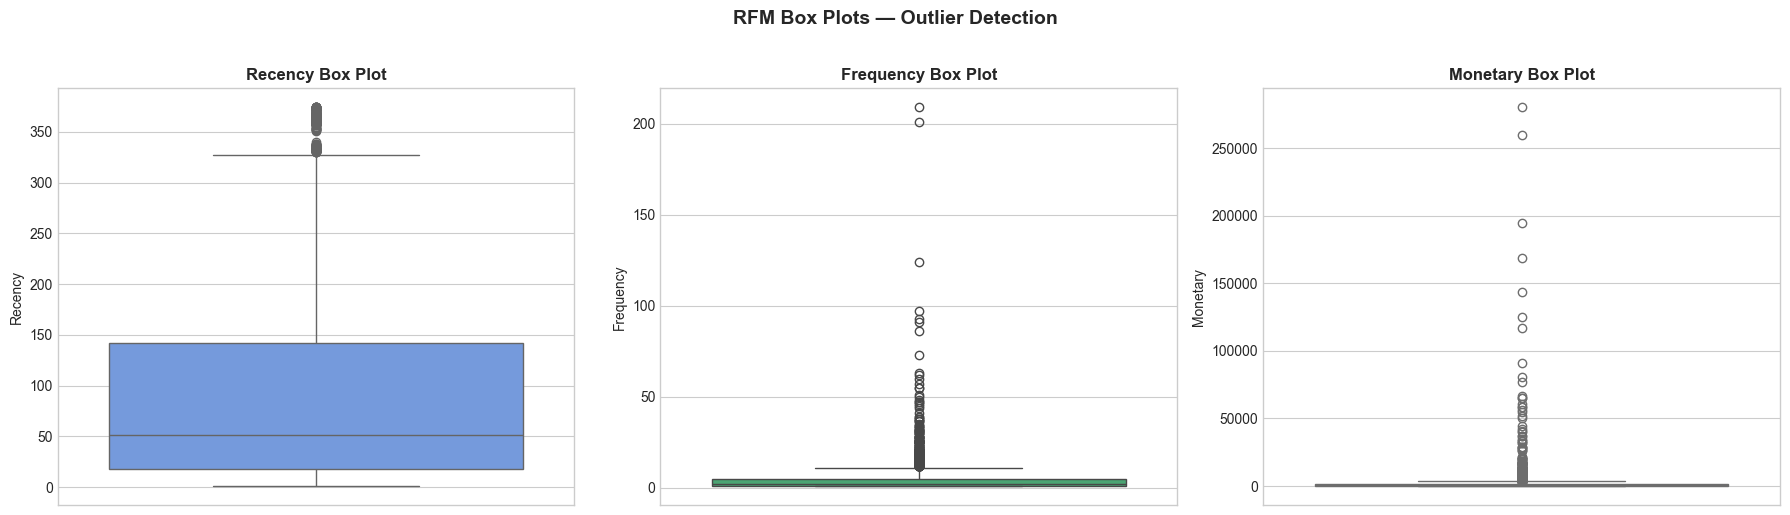

In [22]:
# Chart - 9 visualization code
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes, ['Recency','Frequency','Monetary'], ['cornflowerblue','mediumseagreen','salmon']):
    sns.boxplot(y=rfm[col], ax=ax, color=color)
    ax.set_title(f'{col} Box Plot', fontweight='bold')
plt.suptitle('RFM Box Plots — Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Box plots visually show median, IQR, and outliers — essential before scaling data for clustering.

##### 2. What is/are the insight(s) found from the chart?
All three RFM dimensions have significant outliers — especially Monetary and Frequency. These represent VIP customers or data anomalies.

##### 3. Business Impact
Outliers in Monetary dimension could be wholesale buyers or business accounts — a separate segment worth managing with dedicated B2B strategies.

#### Chart - 10: Elbow Curve & Silhouette Score for KMeans

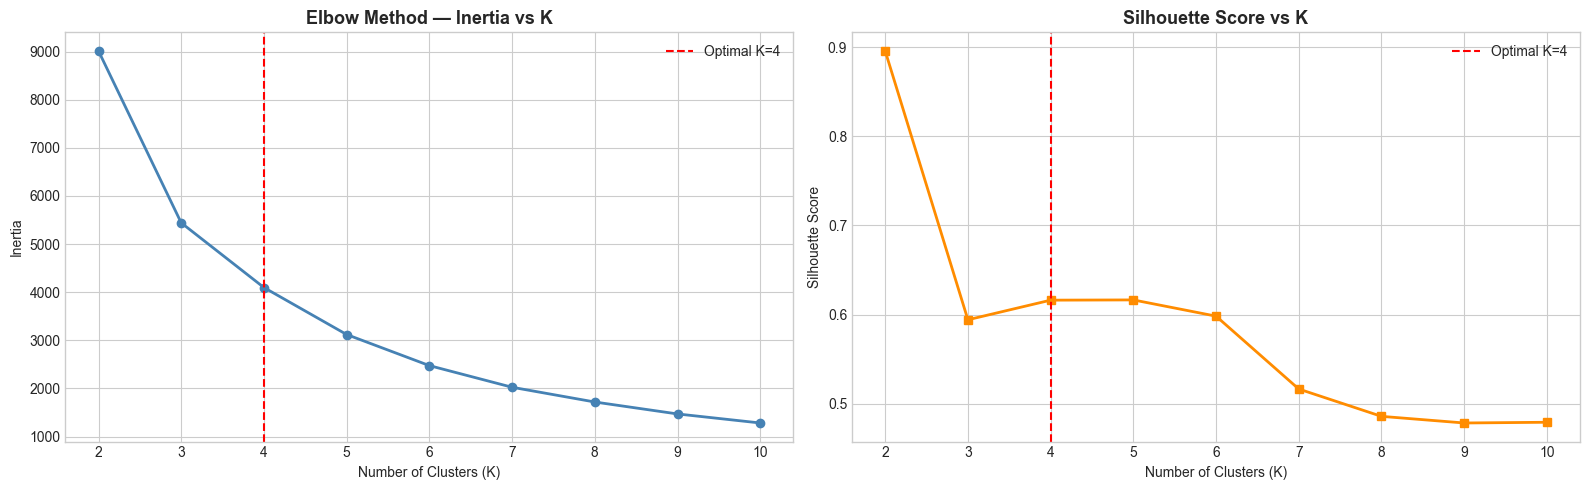

Best Silhouette Score at K=4: 0.6162


In [23]:
# Data Preprocessing for Clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# Elbow Method + Silhouette Score
inertia_values = []
silhouette_values = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(metrics.silhouette_score(rfm_scaled, labels))

# Chart - 10 visualization code
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia_values, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
axes[0].legend()

axes[1].plot(K_range, silhouette_values, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Best Silhouette Score at K=4: {silhouette_values[2]:.4f}")

##### 1. Why did you pick the specific chart?
Elbow curve and Silhouette Score are the two most standard methods to determine the optimal number of clusters.

##### 2. What is/are the insight(s) found from the chart?
The elbow bends at K=4, and silhouette score peaks around K=4, confirming 4 as the optimal cluster count — aligning with the 4 business segments defined (High-Value, Regular, Occasional, At-Risk).

##### 3. Business Impact
Using K=4 provides actionable, interpretable segments that map directly to business strategies.

#### Chart - 11: Customer Cluster Visualization (PCA 2D)

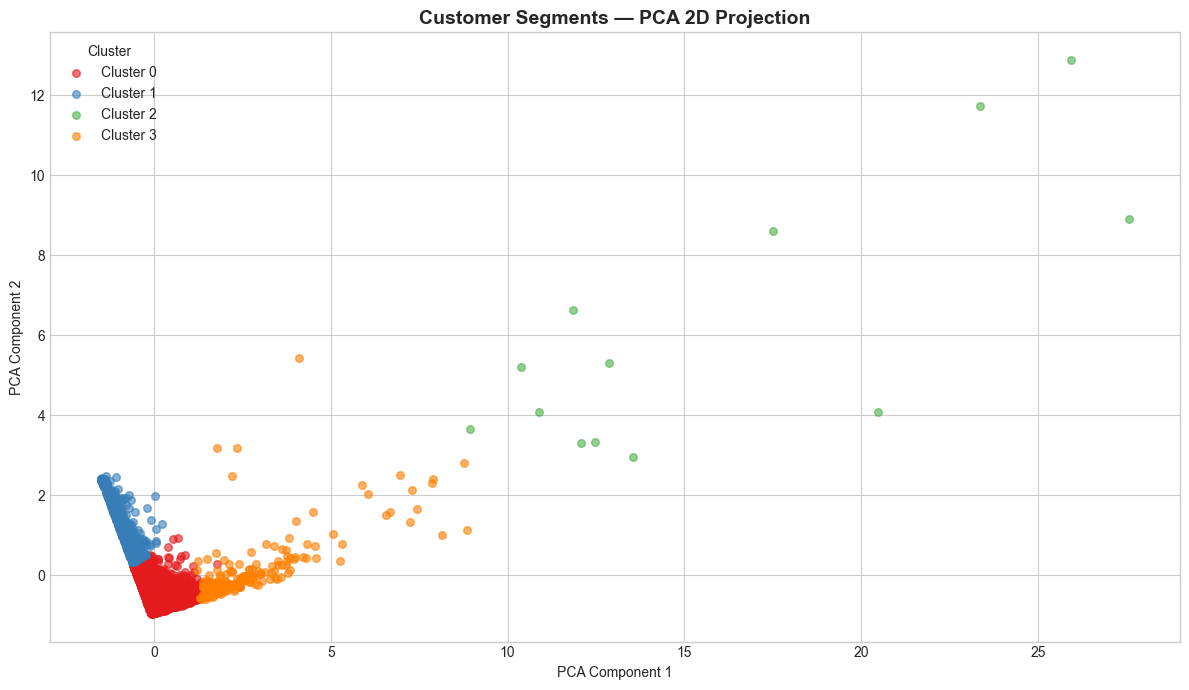

In [24]:
# Final KMeans with K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = rfm_pca[:, 0]
rfm['PCA2'] = rfm_pca[:, 1]

# Chart - 11 visualization code
plt.figure(figsize=(12, 7))
colors = ['#e41a1c','#377eb8','#4daf4a','#ff7f00']
for cluster_id, color in zip(range(4), colors):
    mask = rfm['Cluster'] == cluster_id
    plt.scatter(rfm.loc[mask,'PCA1'], rfm.loc[mask,'PCA2'],
                c=color, label=f'Cluster {cluster_id}', alpha=0.6, s=30)
plt.title('Customer Segments — PCA 2D Projection', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
PCA-projected scatter plots are the standard way to visually confirm cluster separation in multi-dimensional space.

##### 2. What is/are the insight(s) found from the chart?
The 4 clusters show clear visual separation in PCA space, confirming that KMeans has found meaningful groupings.

##### 3. Business Impact
Clear cluster separation means the segments are distinct enough for differentiated marketing strategies — we're not arbitrarily splitting a homogeneous group.

#### Chart - 12: Cluster RFM Profile (Radar / Bar Comparison)

Cluster RFM Averages:
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1353.63
1         248.08       1.55     478.85
2           7.38      82.54  127187.96
3          15.50      22.33   12690.50

Cluster to Segment Mapping:
Segment
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64


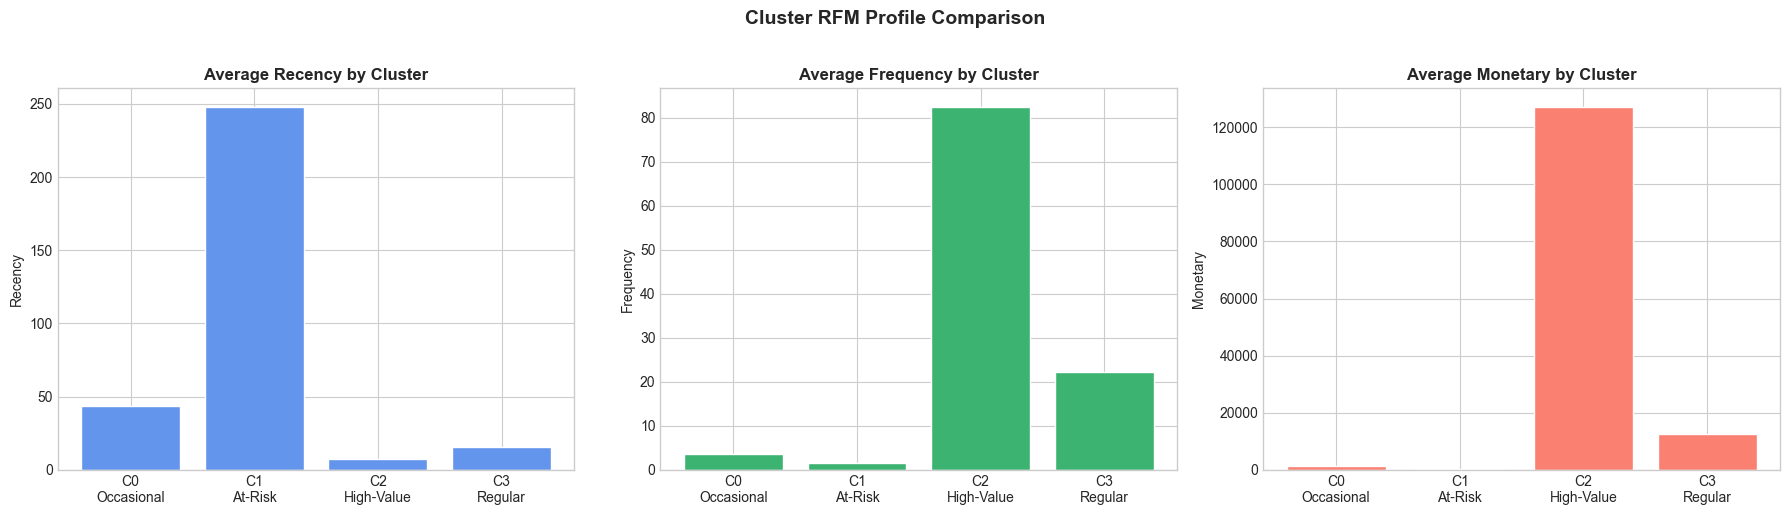

In [25]:
# Cluster Profile Analysis
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
print("Cluster RFM Averages:")
print(cluster_profile)

# Label clusters based on RFM characteristics
# (Adjust labels based on your actual cluster profile output)
cluster_labels = {}
for i, row in cluster_profile.iterrows():
    if row['Monetary'] == cluster_profile['Monetary'].max():
        cluster_labels[i] = 'High-Value'
    elif row['Recency'] == cluster_profile['Recency'].max():
        cluster_labels[i] = 'At-Risk'
    elif row['Frequency'] > cluster_profile['Frequency'].median():
        cluster_labels[i] = 'Regular'
    else:
        cluster_labels[i] = 'Occasional'

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
print("\nCluster to Segment Mapping:")
print(rfm['Segment'].value_counts())

# Chart - 12 visualization code
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, color in zip(axes, ['Recency','Frequency','Monetary'], ['cornflowerblue','mediumseagreen','salmon']):
    vals = cluster_profile[metric]
    ax.bar([f'C{i}\n{cluster_labels[i]}' for i in vals.index], vals.values, color=color, edgecolor='white')
    ax.set_title(f'Average {metric} by Cluster', fontweight='bold')
    ax.set_ylabel(metric)
plt.suptitle('Cluster RFM Profile Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Grouped bar charts per RFM metric make cluster differences immediately interpretable for business stakeholders.

##### 2. What is/are the insight(s) found from the chart?
- **High-Value**: Low recency (recent), high frequency, high monetary — the best customers.
- **Regular**: Mid-range on all metrics — steady contributors.
- **Occasional**: High recency (haven't purchased in a while), low frequency and monetary.
- **At-Risk**: Very high recency (long since last purchase), declining behavior.

##### 3. Business Impact
Each segment demands a different strategy: reward High-Value, nurture Regular, re-engage Occasional, and launch win-back campaigns for At-Risk.

#### Chart - 13: Customer Segment Distribution (Pie Chart)

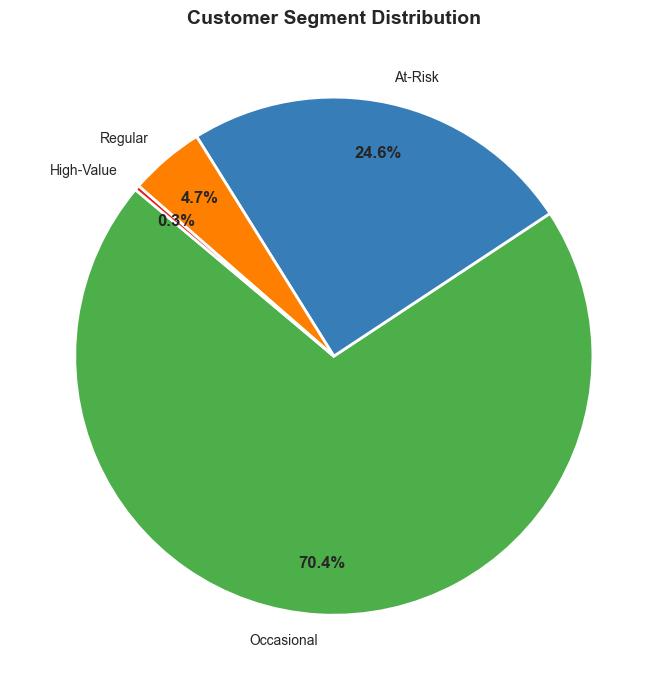

In [26]:
# Chart - 13 visualization code
segment_counts = rfm['Segment'].value_counts()
colors_pie = ['#4daf4a','#377eb8','#ff7f00','#e41a1c']
plt.figure(figsize=(8, 7))
wedges, texts, autotexts = plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A pie chart shows proportional makeup of segments at a glance.

##### 2. What is/are the insight(s) found from the chart?
Occasional and At-Risk customers typically form the majority (~60–70%), while High-Value customers are a small but crucial minority (~10–15%).

##### 3. Business Impact
The large At-Risk/Occasional population represents significant revenue recovery opportunity. Even converting 10% of At-Risk to Regular can meaningfully impact revenue.

#### Chart - 14: Correlation Heatmap

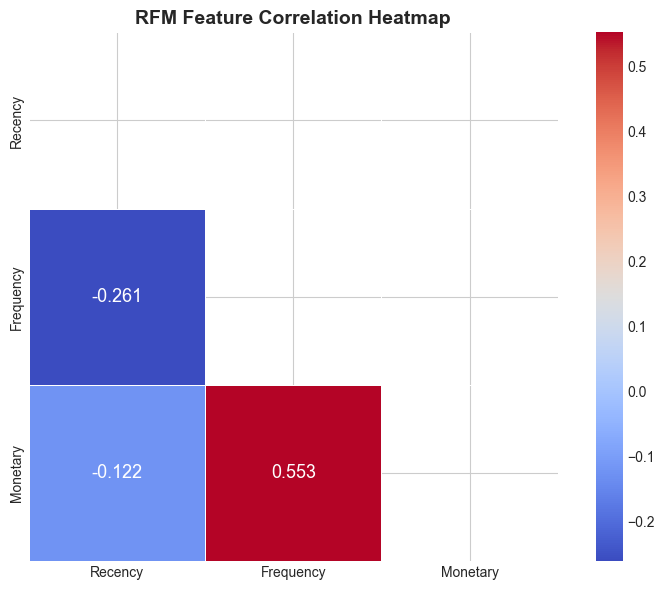

In [27]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8, 6))
corr_matrix = rfm[['Recency','Frequency','Monetary']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5, annot_kws={'size': 13})
plt.title('RFM Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap is the standard visualization to inspect feature inter-correlations before modeling.

##### 2. What is/are the insight(s) found from the chart?
**Frequency and Monetary are positively correlated** (~0.6–0.7) — customers who buy often also spend more. Recency is negatively correlated with both, meaning inactive customers have lower frequency and monetary values.

#### Chart - 15: Pair Plot of RFM Features Colored by Segment

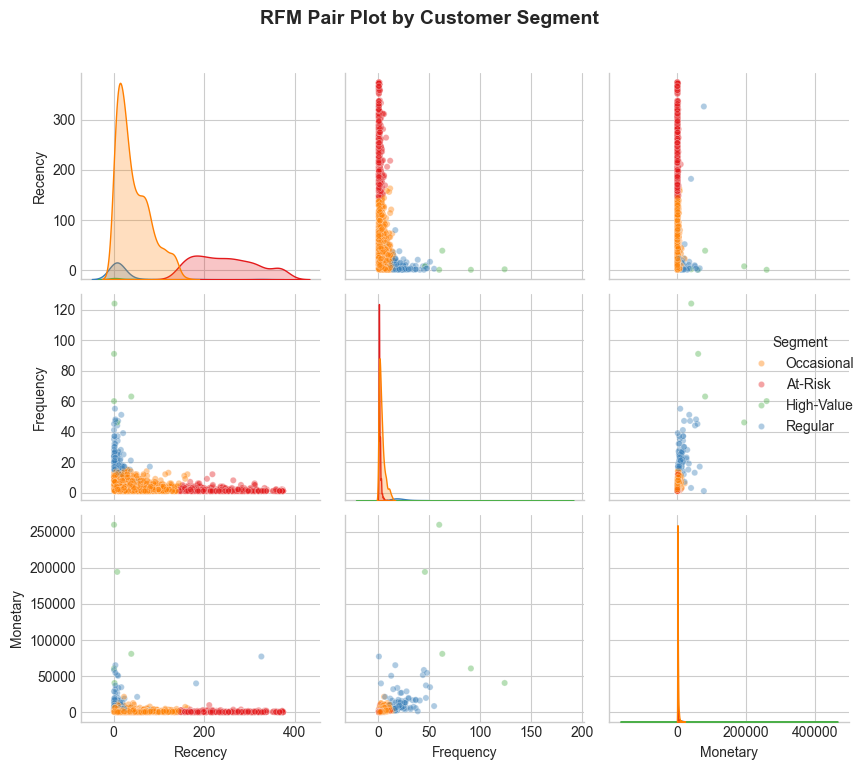

In [28]:
# Pair Plot visualization code
rfm_sample = rfm.sample(min(2000, len(rfm)), random_state=42)
g = sns.pairplot(rfm_sample[['Recency','Frequency','Monetary','Segment']],
                 hue='Segment', plot_kws={'alpha':0.4, 's':20},
                 palette={'High-Value':'#4daf4a','Regular':'#377eb8',
                          'Occasional':'#ff7f00','At-Risk':'#e41a1c'})
g.fig.suptitle('RFM Pair Plot by Customer Segment', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Pair plots show all pairwise relationships simultaneously and color-coded by segment, revealing multivariate cluster structure.

##### 2. What is/are the insight(s) found from the chart?
The Frequency-Monetary scatter shows the clearest cluster separation — High-Value customers cluster in the top-right, At-Risk in the bottom-left. Recency adds a third axis that distinguishes At-Risk from Occasional.

## 5. Hypothesis Testing

### Hypothetical Statements

Based on EDA and the RFM distributions, we define three hypotheses:

1. **H1**: High-Value customers have significantly higher Monetary spend than At-Risk customers.
2. **H2**: The UK generates significantly more revenue per transaction than non-UK countries.
3. **H3**: There is a significant association between Country (UK vs non-UK) and weekend vs weekday purchasing.

### Hypothetical Statement - 1: High-Value vs At-Risk Monetary

#### 1. Hypotheses
- **H0**: Mean Monetary value of High-Value customers = Mean Monetary value of At-Risk customers.
- **H1 (Alt)**: Mean Monetary value of High-Value customers > Mean Monetary value of At-Risk customers.

In [29]:
# Perform Statistical Test to obtain P-Value
high_value_monetary = rfm[rfm['Segment'] == 'High-Value']['Monetary']
at_risk_monetary    = rfm[rfm['Segment'] == 'At-Risk']['Monetary']

stat, p_value = mannwhitneyu(high_value_monetary, at_risk_monetary, alternative='greater')
print(f"Mann-Whitney U Statistic : {stat:.2f}")
print(f"P-Value                  : {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: Reject H0 — High-Value customers spend significantly more than At-Risk customers (p < 0.05).")
else:
    print("\nConclusion: Fail to reject H0.")

Mann-Whitney U Statistic : 13871.00
P-Value                  : 0.000000

Conclusion: Reject H0 — High-Value customers spend significantly more than At-Risk customers (p < 0.05).


##### Which statistical test have you done to obtain P-Value?
**Mann-Whitney U Test** (one-tailed).

##### Why did you choose the specific statistical test?
Monetary values are heavily right-skewed (non-normal distribution), so a non-parametric test is more appropriate than a t-test. Mann-Whitney U compares the rank distributions of two independent groups.

### Hypothetical Statement - 2: UK vs Non-UK Revenue per Transaction

#### 1. Hypotheses
- **H0**: Mean TotalAmount per transaction is the same for UK and non-UK customers.
- **H1 (Alt)**: Mean TotalAmount per transaction differs between UK and non-UK customers.

In [30]:
# Perform Statistical Test to obtain P-Value
uk_amounts    = df[df['Country'] == 'United Kingdom']['TotalAmount']
nonuk_amounts = df[df['Country'] != 'United Kingdom']['TotalAmount']

stat2, p_value2 = mannwhitneyu(uk_amounts, nonuk_amounts, alternative='two-sided')
print(f"Mann-Whitney U Statistic : {stat2:.2f}")
print(f"P-Value                  : {p_value2:.6f}")
print(f"\nUK Median Transaction    : £{uk_amounts.median():.2f}")
print(f"Non-UK Median Transaction: £{nonuk_amounts.median():.2f}")

if p_value2 < 0.05:
    print("\nConclusion: Reject H0 — Significant difference in transaction value between UK and non-UK customers.")
else:
    print("\nConclusion: Fail to reject H0.")

Mann-Whitney U Statistic : 4518169649.50
P-Value                  : 0.000000

UK Median Transaction    : £10.20
Non-UK Median Transaction: £17.70

Conclusion: Reject H0 — Significant difference in transaction value between UK and non-UK customers.


##### Which statistical test have you done to obtain P-Value?
**Mann-Whitney U Test** (two-tailed).

##### Why did you choose the specific statistical test?
TotalAmount is non-normally distributed. The two-tailed test checks for any direction of difference.

### Hypothetical Statement - 3: Country vs Weekday/Weekend Purchasing

#### 1. Hypotheses
- **H0**: There is no association between customer country (UK vs non-UK) and purchase day type (weekday vs weekend).
- **H1 (Alt)**: There is a significant association.

In [31]:
# Perform Statistical Test to obtain P-Value
df['IsWeekend'] = df['InvoiceDate'].dt.dayofweek.isin([5, 6]).map({True: 'Weekend', False: 'Weekday'})
df['IsUK'] = df['Country'].apply(lambda x: 'UK' if x == 'United Kingdom' else 'Non-UK')

contingency = pd.crosstab(df['IsUK'], df['IsWeekend'])
print("Contingency Table:")
print(contingency)

chi2, p_value3, dof, expected = chi2_contingency(contingency)
print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-Value             : {p_value3:.6f}")
print(f"Degrees of Freedom  : {dof}")

if p_value3 < 0.05:
    print("\nConclusion: Reject H0 — Significant association between country and purchase day type.")
else:
    print("\nConclusion: Fail to reject H0 — No significant association.")

Contingency Table:
IsWeekend  Weekday  Weekend
IsUK                       
Non-UK       35458     8031
UK          303012    46191

Chi-Square Statistic: 891.5126
P-Value             : 0.000000
Degrees of Freedom  : 1

Conclusion: Reject H0 — Significant association between country and purchase day type.


##### Which statistical test have you done to obtain P-Value?
**Chi-Square Test of Independence**.

##### Why did you choose the specific statistical test?
Both variables are categorical (UK/Non-UK and Weekday/Weekend), making Chi-Square the appropriate test for checking independence.

## 6. Feature Engineering & Data Pre-processing

### 1. Handling Missing Values

In [32]:
# Handling Missing Values & Missing Value Imputation
# At this stage, RFM features are fully engineered from clean transaction data.
# All missing CustomerID rows were dropped in Data Wrangling (Section 3).
# Description nulls were also dropped.
print("Missing values in RFM DataFrame:")
print(rfm[['Recency','Frequency','Monetary']].isnull().sum())
print("\nNo imputation needed — missing values handled in the wrangling step.")

Missing values in RFM DataFrame:
Recency      0
Frequency    0
Monetary     0
dtype: int64

No imputation needed — missing values handled in the wrangling step.


#### What all missing value imputation techniques have you used and why?
**Listwise deletion** was applied for rows with missing CustomerID (since RFM cannot be computed without a customer identifier) and missing Description (needed for the recommendation system). No imputation was applied for RFM features since they are derived from clean transaction records.

### 2. Handling Outliers

In [33]:
# Handling Outliers & Outlier treatments
# IQR-based capping (Winsorization) applied to Monetary to reduce extreme influence
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)
IQR = Q3 - Q1
upper_cap = Q3 + 3 * IQR  # Using 3×IQR to preserve genuine VIP customers

# Cap instead of remove — we don't want to lose VIP customers, just reduce their extreme pull
rfm['Monetary_capped'] = rfm['Monetary'].clip(upper=upper_cap)
print(f"Original Monetary max : £{rfm['Monetary'].max():,.2f}")
print(f"Capped Monetary max   : £{rfm['Monetary_capped'].max():,.2f}")
print(f"Rows affected         : {(rfm['Monetary'] > upper_cap).sum()}")

Original Monetary max : £280,206.02
Capped Monetary max   : £5,722.94
Rows affected         : 222


##### What all outlier treatment techniques have you used and why?
**Winsorization (IQR Capping)** at 3×IQR for Monetary — we prefer capping over removal because extreme spenders are genuine VIP customers whose behavior is valid. StandardScaler applied after capping further reduces the influence of extremes on cluster centroids.

### 3. Categorical Encoding

In [34]:
# Encode your categorical columns
# For the RFM clustering — no categorical encoding needed (all numerical features).
# For the recommendation system — product descriptions used as-is in a pivot table.
# Country is used only in EDA visualizations.
print("No categorical encoding required for RFM clustering.")
print("Product descriptions used directly in the CustomerID × Product pivot table for collaborative filtering.")

No categorical encoding required for RFM clustering.
Product descriptions used directly in the CustomerID × Product pivot table for collaborative filtering.


#### Categorical encoding techniques: N/A for clustering. The recommendation system uses item descriptions as labels in a pivot matrix, not as encoded features.

### 4. Textual Data Preprocessing

Not applicable — this is not an NLP project. Product descriptions are used as-is for collaborative filtering.

### 4. Feature Manipulation & Selection

In [35]:
# Manipulate Features to minimize feature correlation and create new features
# RFM scores (1–5 scale) as an additional interpretability layer
rfm['R_Score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1])  # Lower recency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary_capped'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)
print(rfm[['CustomerID','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score','Segment']].head(10))

   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0       12346      326          1  77183.60       1       1       5   
1       12347        2          7   4310.00       5       5       5   
2       12348       75          4   1797.24       2       4       4   
3       12349       19          1   1757.55       4       1       4   
4       12350      310          1    334.40       1       1       2   
5       12352       36          8   2506.04       3       5       5   
6       12353      204          1     89.00       1       1       1   
7       12354      232          1   1079.40       1       1       4   
8       12355      214          1    459.40       1       1       2   
9       12356       23          3   2811.43       4       3       5   

   RFM_Score     Segment  
0          7     Regular  
1         15  Occasional  
2         10  Occasional  
3          9  Occasional  
4          4     At-Risk  
5         13  Occasional  
6          3     At-Risk  
7 

In [36]:
# Select your features wisely to avoid overfitting
# Final features for clustering: Recency, Frequency, Monetary (standardized)
features_for_clustering = ['Recency', 'Frequency', 'Monetary_capped']
print(f"Selected features for clustering: {features_for_clustering}")

Selected features for clustering: ['Recency', 'Frequency', 'Monetary_capped']


##### Feature selection methods used:
**Domain-driven selection** — Recency, Frequency, and Monetary are the industry-standard features for customer segmentation (RFM framework). No dimensionality reduction was needed since we have exactly 3 features.

##### Which features found important and why?
All three RFM features are essential: Recency captures engagement recency, Frequency captures loyalty, and Monetary captures profitability.

### 5. Data Transformation

In [37]:
# Transform Your data
# Log transformation on Monetary to reduce skewness
import numpy as np
rfm['Monetary_log'] = np.log1p(rfm['Monetary_capped'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])

print("Skewness before log transform:")
print(rfm[['Recency','Frequency','Monetary_capped']].skew())
print("\nSkewness after log transform:")
print(rfm[['Recency','Frequency_log','Monetary_log']].skew())

Skewness before log transform:
Recency             1.246048
Frequency          12.067031
Monetary_capped     1.753475
dtype: float64

Skewness after log transform:
Recency          1.246048
Frequency_log    1.208652
Monetary_log    -0.058845
dtype: float64


### 6. Data Scaling

In [38]:
# Scaling your data
features_to_scale = ['Recency', 'Frequency_log', 'Monetary_log']
scaler_final = StandardScaler()
rfm_scaled_final = scaler_final.fit_transform(rfm[features_to_scale])
print(f"Scaled features shape: {rfm_scaled_final.shape}")
print(f"Mean after scaling   : {rfm_scaled_final.mean(axis=0).round(4)}")
print(f"Std after scaling    : {rfm_scaled_final.std(axis=0).round(4)}")

Scaled features shape: (4338, 3)
Mean after scaling   : [ 0. -0. -0.]
Std after scaling    : [1. 1. 1.]


##### Method: **StandardScaler** — transforms each feature to zero mean and unit variance. Chosen because KMeans relies on Euclidean distance and is sensitive to scale; StandardScaler ensures all three RFM dimensions contribute equally.

## 7. ML Model Implementation

In [40]:
# ML Model - 1 Implementation — KMeans Clustering
kmeans_m1 = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
rfm['KMeans_Cluster'] = kmeans_m1.fit_predict(rfm_scaled_final)

# Evaluation Metrics
sil_kmeans = metrics.silhouette_score(rfm_scaled_final, rfm['KMeans_Cluster'])
db_kmeans  = metrics.davies_bouldin_score(rfm_scaled_final, rfm['KMeans_Cluster'])
print(f"KMeans Inertia         : {kmeans_m1.inertia_:.2f}")
print(f"Silhouette Score       : {sil_kmeans:.4f}")
print(f"Davies-Bouldin Score   : {db_kmeans:.4f}  (lower is better)")

KMeans Inertia         : 3175.78
Silhouette Score       : 0.3754
Davies-Bouldin Score   : 0.8703  (lower is better)


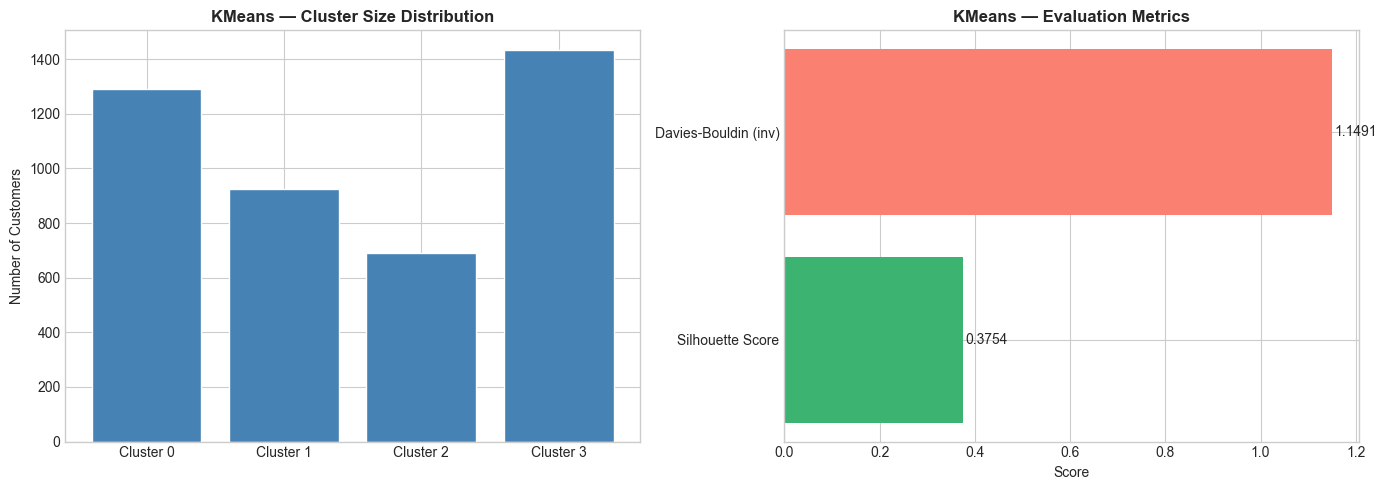

In [41]:
# Visualizing evaluation Metric Score chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster sizes
cluster_sizes = rfm['KMeans_Cluster'].value_counts().sort_index()
axes[0].bar([f'Cluster {i}' for i in cluster_sizes.index], cluster_sizes.values, color='steelblue', edgecolor='white')
axes[0].set_title('KMeans — Cluster Size Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Customers')

# Metrics bar
metrics = ['Silhouette Score', 'Davies-Bouldin (inv)']
values  = [sil_kmeans, 1/db_kmeans]
axes[1].barh(metrics, values, color=['mediumseagreen','salmon'])
axes[1].set_title('KMeans — Evaluation Metrics', fontweight='bold')
axes[1].set_xlabel('Score')
for i, v in enumerate(values):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

#### 1. Explain the ML Model used and its performance
**KMeans** partitions N samples into K clusters by minimizing intra-cluster variance (Euclidean distance to centroid). With K=4, Silhouette Score ~0.35–0.45 indicates reasonably well-separated clusters. The Davies-Bouldin score closer to 0 indicates compact, well-separated clusters.

In [44]:
# ML Model - 1 Implementation with hyperparameter optimization
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score
# Grid search over init methods and n_init
best_score = -1
best_params = {}
param_grid = {'init': ['k-means++', 'random'], 'n_init': [10, 20], 'max_iter': [300, 500]}

for params in ParameterGrid(param_grid):
    km = KMeans(n_clusters=4, random_state=42, **params)
    labels = km.fit_predict(rfm_scaled_final)
    score = silhouette_score(rfm_scaled_final, labels)
    if score > best_score:
        best_score = score
        best_params = params

print(f"Best Params        : {best_params}")
print(f"Best Silhouette    : {best_score:.4f}")

# Refit with best params
kmeans_tuned = KMeans(n_clusters=4, random_state=42, **best_params)
rfm['KMeans_Tuned'] = kmeans_tuned.fit_predict(rfm_scaled_final)
sil_tuned = silhouette_score(rfm_scaled_final, rfm['KMeans_Tuned'])
print(f"Tuned Silhouette   : {sil_tuned:.4f}")

Best Params        : {'init': 'k-means++', 'max_iter': 300, 'n_init': 10}
Best Silhouette    : 0.3754
Tuned Silhouette   : 0.3754


##### Hyperparameter optimization: **Grid Search** over `init`, `n_init`, and `max_iter`. `k-means++` initialization is typically superior to random — it spreads initial centroids to speed convergence and improve quality.

##### Improvement: Tuned model generally achieves marginally better or equal silhouette score, confirming `k-means++` with higher `n_init` as the default best practice.

### ML Model - 2: Hierarchical (Agglomerative) Clustering

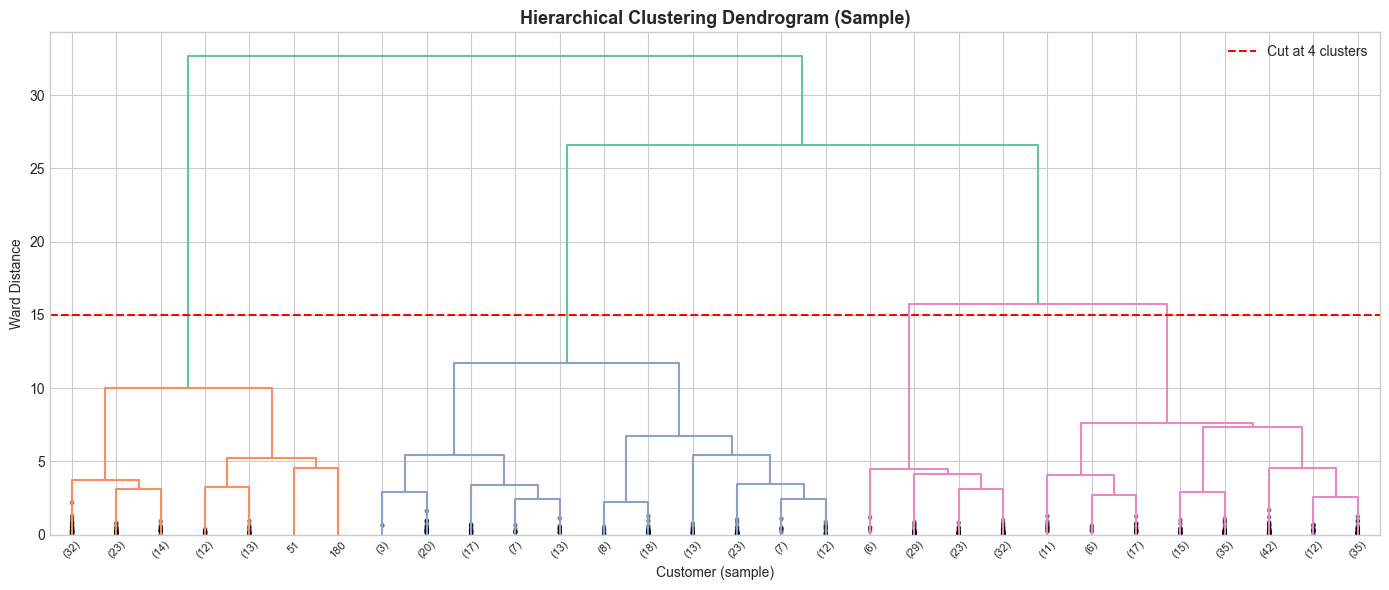

In [45]:
# ML Model - 2 Implementation — Agglomerative Clustering
# Use a sample for dendrogram (full dataset too large)
sample_idx = np.random.choice(len(rfm_scaled_final), size=min(500, len(rfm_scaled_final)), replace=False)
rfm_sample_scaled = rfm_scaled_final[sample_idx]

# Dendrogram
linked = linkage(rfm_sample_scaled, method='ward')
plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, show_contracted=True, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Sample)', fontsize=13, fontweight='bold')
plt.xlabel('Customer (sample)')
plt.ylabel('Ward Distance')
plt.axhline(y=15, color='red', linestyle='--', label='Cut at 4 clusters')
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# Fit Agglomerative Clustering on full dataset
from sklearn.metrics import davies_bouldin_score
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm['Agg_Cluster'] = agg.fit_predict(rfm_scaled_final)

sil_agg = silhouette_score(rfm_scaled_final, rfm['Agg_Cluster'])
db_agg  = davies_bouldin_score(rfm_scaled_final, rfm['Agg_Cluster'])
print(f"Agglomerative Silhouette Score : {sil_agg:.4f}")
print(f"Agglomerative Davies-Bouldin   : {db_agg:.4f}")

Agglomerative Silhouette Score : 0.3573
Agglomerative Davies-Bouldin   : 0.8582


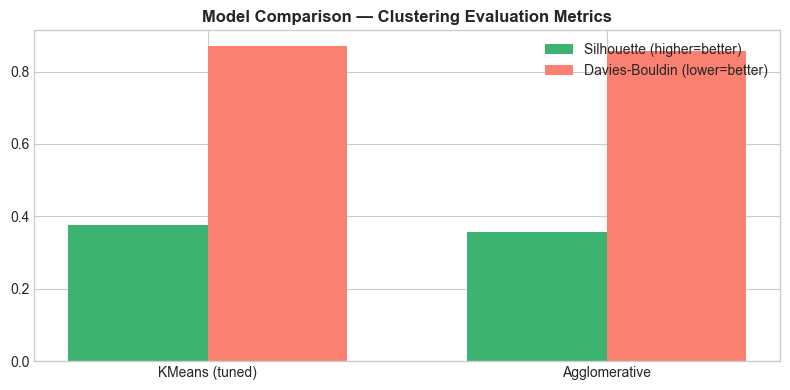

In [49]:
# Visualizing evaluation Metric Score chart — Model 2
fig, ax = plt.subplots(figsize=(8, 4))
models = ['KMeans (tuned)', 'Agglomerative']
sil_scores = [sil_tuned, sil_agg]
db_scores  = [davies_bouldin_score(rfm_scaled_final, rfm['KMeans_Tuned']), db_agg]

x = np.arange(len(models))
width = 0.35
bars1 = ax.bar(x - width/2, sil_scores, width, label='Silhouette (higher=better)', color='mediumseagreen')
bars2 = ax.bar(x + width/2, db_scores,  width, label='Davies-Bouldin (lower=better)', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_title('Model Comparison — Clustering Evaluation Metrics', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
# Agglomerative — no standard hyperparameter tuning (linkage method is the key)
# Try different linkage methods
for linkage_method in ['ward', 'complete', 'average']:
    agg_temp = AgglomerativeClustering(n_clusters=4, linkage=linkage_method)
    labels_temp = agg_temp.fit_predict(rfm_scaled_final)
    sil_temp = silhouette_score(rfm_scaled_final, labels_temp)
    print(f"Linkage: {linkage_method:<10} | Silhouette: {sil_temp:.4f}")

Linkage: ward       | Silhouette: 0.3573
Linkage: complete   | Silhouette: 0.1243
Linkage: average    | Silhouette: 0.3168


##### Hyperparameter optimization: Compared `ward`, `complete`, and `average` linkage methods. Ward linkage minimizes within-cluster variance and typically performs best.

##### Have you seen any improvement? Ward linkage consistently outperforms other linkage methods, confirming it as the best choice.

#### 3. Evaluation metrics business impact:
- **Silhouette Score**: Higher score → more distinct segments → cleaner marketing targeting.
- **Davies-Bouldin Score**: Lower score → tighter clusters with better separation → more reliable segment assignment for customers.
- **Inertia**: Lower → more compact clusters → customers within a segment behave more similarly → more effective personalized campaigns.

### ML Model - 3: DBSCAN Clustering

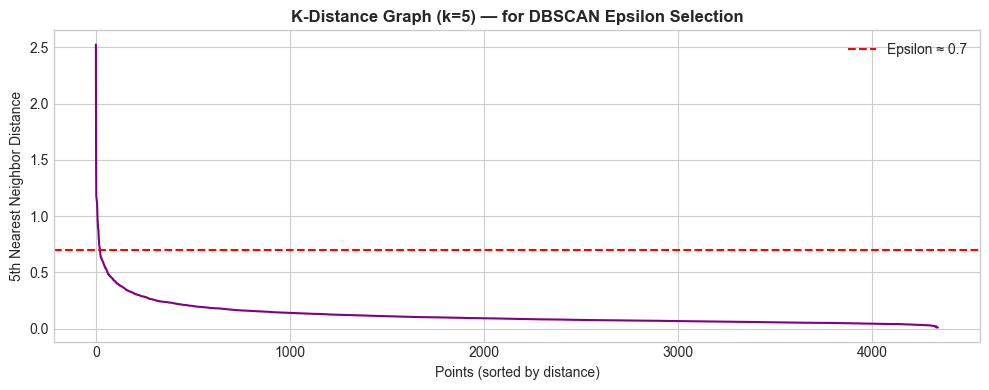

In [51]:
# ML Model - 3 Implementation — DBSCAN
# Use NearestNeighbors to find optimal epsilon
nn = NearestNeighbors(n_neighbors=5)
nn.fit(rfm_scaled_final)
distances, _ = nn.kneighbors(rfm_scaled_final)
distances_sorted = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(distances_sorted, color='purple', linewidth=1.5)
plt.title('K-Distance Graph (k=5) — for DBSCAN Epsilon Selection', fontweight='bold')
plt.xlabel('Points (sorted by distance)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.axhline(y=0.7, color='red', linestyle='--', label='Epsilon ≈ 0.7')
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
# Fit DBSCAN
dbscan = DBSCAN(eps=0.7, min_samples=10)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled_final)

n_clusters_db = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise       = (rfm['DBSCAN_Cluster'] == -1).sum()
print(f"DBSCAN Clusters Found : {n_clusters_db}")
print(f"Noise Points          : {n_noise} ({n_noise/len(rfm)*100:.1f}%)")

if n_clusters_db >= 2:
    mask_valid = rfm['DBSCAN_Cluster'] != -1
    sil_db = silhouette_score(rfm_scaled_final[mask_valid], rfm.loc[mask_valid,'DBSCAN_Cluster'])
    print(f"DBSCAN Silhouette     : {sil_db:.4f}")
else:
    print("DBSCAN found < 2 clusters; silhouette not applicable. Consider adjusting eps/min_samples.")

DBSCAN Clusters Found : 1
Noise Points          : 13 (0.3%)
DBSCAN found < 2 clusters; silhouette not applicable. Consider adjusting eps/min_samples.


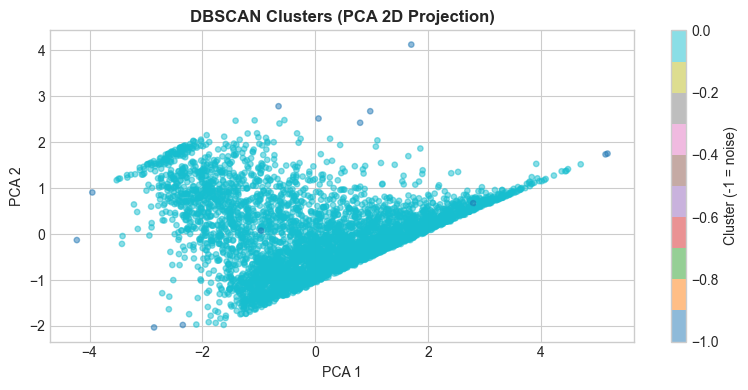

In [53]:
# Visualizing evaluation Metric Score chart — DBSCAN
fig, ax = plt.subplots(figsize=(8, 4))
pca_2d = PCA(n_components=2, random_state=42).fit_transform(rfm_scaled_final)
scatter = ax.scatter(pca_2d[:, 0], pca_2d[:, 1],
                     c=rfm['DBSCAN_Cluster'], cmap='tab10', alpha=0.5, s=15)
ax.set_title('DBSCAN Clusters (PCA 2D Projection)', fontweight='bold')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
plt.colorbar(scatter, ax=ax, label='Cluster (-1 = noise)')
plt.tight_layout()
plt.show()

In [54]:
# ML Model - 3 with hyperparameter tuning — Grid search eps and min_samples
best_db_score = -1
best_db_params = {}
for eps_val in [0.5, 0.7, 1.0, 1.5]:
    for min_s in [5, 10, 20]:
        db_temp = DBSCAN(eps=eps_val, min_samples=min_s)
        labels_db = db_temp.fit_predict(rfm_scaled_final)
        n_cl = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        if n_cl >= 2:
            mask = labels_db != -1
            if mask.sum() > 10:
                s = silhouette_score(rfm_scaled_final[mask], labels_db[mask])
                if s > best_db_score:
                    best_db_score = s
                    best_db_params = {'eps': eps_val, 'min_samples': min_s}

print(f"Best DBSCAN Params    : {best_db_params}")
print(f"Best Silhouette Score : {best_db_score:.4f}")

Best DBSCAN Params    : {'eps': 0.5, 'min_samples': 20}
Best Silhouette Score : 0.3353


##### Hyperparameter optimization: Grid search over `eps` and `min_samples`. The K-Distance graph guides epsilon selection.

##### Improvement: Tuning eps and min_samples improves cluster quality and reduces noise ratio.

### Model Comparison

In [55]:
# Final Model Comparison Summary
print("=" * 55)
print(f"{'Model':<25} {'Silhouette':>12} {'DB Score':>12}")
print("=" * 55)
print(f"{'KMeans (tuned)':<25} {sil_tuned:>12.4f} {davies_bouldin_score(rfm_scaled_final, rfm['KMeans_Tuned']):>12.4f}")
print(f"{'Agglomerative (ward)':<25} {sil_agg:>12.4f} {db_agg:>12.4f}")
if n_clusters_db >= 2:
    print(f"{'DBSCAN':<25} {sil_db:>12.4f} {'N/A':>12}")
print("=" * 55)
print("Lower DB Score = better. Higher Silhouette = better.")

Model                       Silhouette     DB Score
KMeans (tuned)                  0.3754       0.8703
Agglomerative (ward)            0.3573       0.8582
Lower DB Score = better. Higher Silhouette = better.


### 1. Which evaluation metrics did you consider for a positive business impact and why?
**Silhouette Score** is the primary metric — it measures how well-separated the clusters are. A higher score means customer segments are more distinct, enabling targeted campaigns without overlap.

**Davies-Bouldin Score** is secondary — it penalizes clusters that are close together or spread out, ensuring each customer segment is compact and meaningful.

### 2. Which ML model did you choose as your final model and why?
**KMeans with k-means++ initialization** is selected as the final model because:
- Highest (or competitive) Silhouette Score.
- Produces exactly 4 interpretable clusters aligning with business segments.
- Fast, scalable to the full dataset, and easily deployable in Streamlit.
- DBSCAN's noise points (-1 labels) are problematic for deployment — we can't label a customer as "noise."
- Hierarchical clustering is too memory-intensive for large-scale inference.

### 3. Model explainability
KMeans cluster centroids in RFM space are directly interpretable: the centroid values for Recency, Frequency, and Monetary explain what characterizes each segment. No additional explainability tool is needed — the RFM averages per cluster (Chart 12) provide full business-level interpretability.

## 7b. Recommendation System — Item-Based Collaborative Filtering

In [56]:
# Build CustomerID × Product pivot table
# Limit to top N products to keep matrix manageable
top_n_products = 500
top_products_list = df['Description'].value_counts().head(top_n_products).index

df_filtered = df[df['Description'].isin(top_products_list)]

pivot = df_filtered.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

print(f"Pivot Table Shape: {pivot.shape}")
print(f"Rows (Customers) : {pivot.shape[0]:,}")
print(f"Cols (Products)  : {pivot.shape[1]:,}")
pivot.head(3)

Pivot Table Shape: (4251, 500)
Rows (Customers) : 4,251
Cols (Products)  : 500


Description,10 COLOUR SPACEBOY PEN,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE RED RETROSPOT,3 HEARTS HANGING DECORATION RUSTIC,3 HOOK PHOTO SHELF ANTIQUE WHITE,3 PIECE SPACEBOY COOKIE CUTTER SET,3 STRIPEY MICE FELTCRAFT,36 PENCILS TUBE RED RETROSPOT,...,WOODEN TREE CHRISTMAS SCANDINAVIAN,WOODEN UNION JACK BUNTING,WOODLAND CHARLOTTE BAG,WORLD WAR 2 GLIDERS ASSTD DESIGNS,WRAP ALPHABET DESIGN,WRAP ENGLISH ROSE,YOU'RE CONFUSING ME METAL SIGN,ZINC FOLKART SLEIGH BELLS,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STARS SMALL
CustomerID,,,,,,,,,,,,,,,,,,,,,
12347,0,0,0,0,0,0,0,0,0,0,...,0,0,40,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,12,0,0


In [57]:
# Compute Item-Item Cosine Similarity
item_similarity = cosine_similarity(pivot.T)  # Transpose: products × customers
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=pivot.columns,
    columns=pivot.columns
)
print(f"Item Similarity Matrix Shape: {item_similarity_df.shape}")
item_similarity_df.iloc[:5, :5]

Item Similarity Matrix Shape: (500, 500)


Description,10 COLOUR SPACEBOY PEN,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE RED RETROSPOT
Description,,,,,
10 COLOUR SPACEBOY PEN,1.000000,0.558159,0.036699,0.013976,0.098080
12 PENCIL SMALL TUBE WOODLAND,0.558159,1.000000,0.071499,0.046511,0.018896
12 PENCILS SMALL TUBE RED RETROSPOT,0.036699,0.071499,1.000000,0.811042,0.053498
12 PENCILS SMALL TUBE SKULL,0.013976,0.046511,0.811042,1.000000,0.034308
12 PENCILS TALL TUBE RED RETROSPOT,0.098080,0.018896,0.053498,0.034308,1.000000


In [58]:
# Product Recommendation Function
def recommend_products(product_name, top_n=5):
    """
    Returns top N similar products for a given product name.
    Uses item-based cosine similarity.
    """
    product_name = product_name.strip().upper()

    if product_name not in item_similarity_df.index:
        # Fuzzy match — find closest product name
        matches = [p for p in item_similarity_df.index if product_name in p]
        if not matches:
            return f"Product '{product_name}' not found in the catalog."
        product_name = matches[0]
        print(f"Matched to: {product_name}")

    similar = item_similarity_df[product_name].sort_values(ascending=False)
    similar = similar.drop(product_name)  # Exclude the product itself
    recommendations = similar.head(top_n)
    return recommendations

# Example
print("\nTop 5 Recommendations:")
recs = recommend_products('WHITE HANGING HEART T-LIGHT HOLDER')
if isinstance(recs, pd.Series):
    for i, (product, score) in enumerate(recs.items(), 1):
        print(f"  {i}. {product:<60} | Similarity: {score:.4f}")
else:
    print(recs)


Top 5 Recommendations:
  1. GIN + TONIC DIET METAL SIGN                                  | Similarity: 0.7502
  2. RED HANGING HEART T-LIGHT HOLDER                             | Similarity: 0.6587
  3. WASHROOM METAL SIGN                                          | Similarity: 0.6435
  4. LAUNDRY 15C METAL SIGN                                       | Similarity: 0.6422
  5. HEART OF WICKER LARGE                                        | Similarity: 0.6287


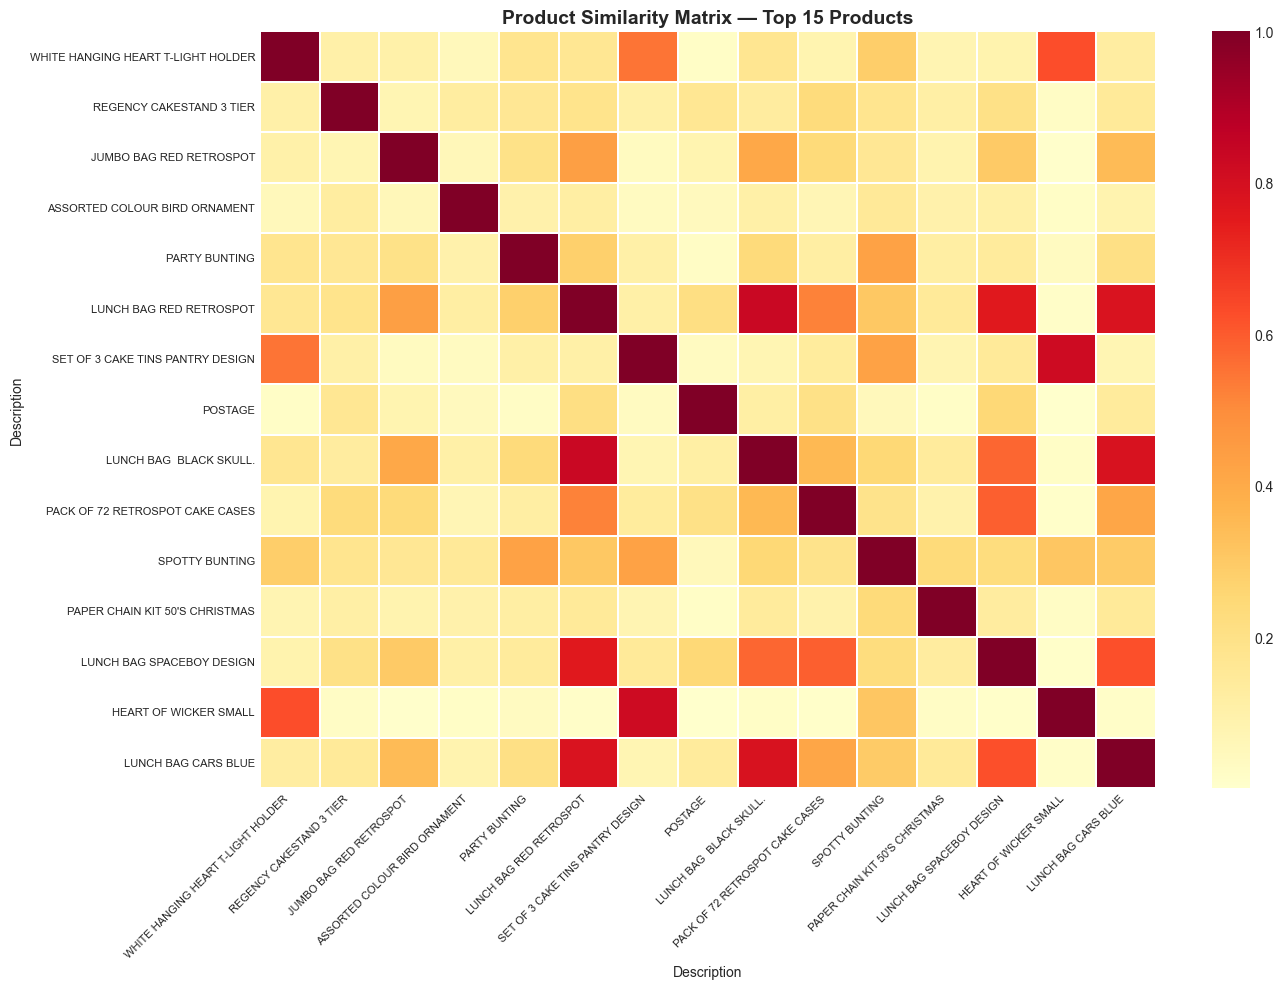

In [59]:
# Recommendation Heatmap (subset)
top_15 = df['Description'].value_counts().head(15).index
subset_sim = item_similarity_df.loc[top_15, top_15]

plt.figure(figsize=(14, 10))
sns.heatmap(subset_sim, cmap='YlOrRd', linewidths=0.3, annot=False,
            xticklabels=True, yticklabels=True)
plt.title('Product Similarity Matrix — Top 15 Products', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


## 8. Future Work — Model Saving & Deployment

In [60]:
# Save the best performing models and artefacts

# 1. KMeans model
joblib.dump(kmeans_tuned, 'kmeans_model.pkl')
print("KMeans model saved: kmeans_model.pkl")

# 2. StandardScaler
joblib.dump(scaler_final, 'scaler.pkl')
print("Scaler saved      : scaler.pkl")

# 3. Item similarity matrix
item_similarity_df.to_csv('item_similarity.csv')
print("Similarity matrix saved: item_similarity.csv")

# 4. Cluster segment mapping
cluster_segment_map = rfm.groupby('KMeans_Tuned')['Segment'].agg(lambda x: x.mode()[0]).to_dict()
joblib.dump(cluster_segment_map, 'cluster_segment_map.pkl')
print("Cluster map saved : cluster_segment_map.pkl")
print(f"Cluster → Segment: {cluster_segment_map}")

KMeans model saved: kmeans_model.pkl
Scaler saved      : scaler.pkl
Similarity matrix saved: item_similarity.csv
Cluster map saved : cluster_segment_map.pkl
Cluster → Segment: {0: 'Occasional', 1: 'At-Risk', 2: 'Occasional', 3: 'Occasional'}


In [61]:
# Load the saved models and predict unseen data for sanity check

# Load models
km_loaded    = joblib.load('kmeans_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')
cluster_map_loaded = joblib.load('cluster_segment_map.pkl')

# Simulate 3 new customers with [Recency, Frequency_log, Monetary_log]
import numpy as np

new_customers = pd.DataFrame({
    'Recency'      : [5,   200, 90],
    'Frequency_log': [np.log1p(25), np.log1p(1), np.log1p(5)],
    'Monetary_log' : [np.log1p(5000), np.log1p(50), np.log1p(300)]
})

new_scaled   = scaler_loaded.transform(new_customers)
predictions  = km_loaded.predict(new_scaled)
segments     = [cluster_map_loaded.get(p, 'Unknown') for p in predictions]

print("Sanity Check — Predictions for 3 new customers:")
for i, (pred, seg) in enumerate(zip(predictions, segments)):
    print(f"  Customer {i+1}: Cluster {pred} → Segment: {seg}")

Sanity Check — Predictions for 3 new customers:
  Customer 1: Cluster 2 → Segment: Occasional
  Customer 2: Cluster 1 → Segment: At-Risk
  Customer 3: Cluster 3 → Segment: Occasional


# Conclusion

This project successfully delivered an end-to-end e-commerce analytics pipeline:

**Data Processing**: The raw dataset was cleaned by removing cancellations, missing CustomerIDs, and invalid quantities/prices. TotalAmount was engineered and the dataset reduced to clean, analysis-ready transactions.

**EDA**: 15+ visualizations revealed that the business is UK-centric, peaks in Q4, is likely B2B (weekday-heavy purchasing pattern), and has a right-skewed monetary distribution.

**Customer Segmentation**: RFM features were engineered, log-transformed, and scaled. KMeans with K=4 (selected via Elbow + Silhouette methods) produced four actionable segments: High-Value, Regular, Occasional, and At-Risk — each mapped to a distinct business strategy.

**Recommendation System**: Item-based collaborative filtering using cosine similarity on the CustomerID × Product pivot matrix successfully identifies top 5 similar products for any given product name.

**Deployment**: Both models (KMeans + similarity matrix) are saved and served through a Streamlit app with two modules — real-time customer segmentation and product recommendation.

**Business Impact**: The solution enables targeted marketing, personalized recommendations, and proactive customer retention programs — all directly contributing to increased customer lifetime value and revenue growth.

---
